<a href="https://colab.research.google.com/github/rishith2209/MACHINE-LEARNING/blob/main/AP23110011392_LR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 1: Introduction

In [ ]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt

# Task 2: Dataset

Real estate agent table:

|Area|Distance|Price|
|---|---|---|
|70|3|21200|
|50|1|22010|
|120|9|24305|
|100|2|31500|

You can write the relationship with a 2-variable linear equation:

$
\begin{equation}
y = b + w_1.x_1 + w_2.x_2
\end{equation}
$

In a vector form:

$
\begin{equation}
y = b + (w_1 w_2).\binom{x_1}{x_2}
\end{equation}
$

Where
$
\begin{equation}
W = (w_1 w_2)
\end{equation}
$
and
$
\begin{equation}
X = \binom{x_1}{x_2}
\end{equation}
$

In [ ]:
def generate_examples(num=1000):
    W = [1.0, -3.0]
    b = 1.0

    W = np.reshape(W, (2, 1))
    X = np.random.randn(num, 2)
    y = b + np.dot(X, W)
    y = np.reshape(y, (num,1))
    return X, y

In [ ]:
X, y = generate_examples()

In [ ]:
print(X.shape, y.shape)

(1000, 2) (1000, 1)


In [ ]:
print(X[0], y[0])

[1.57366266 1.05171282] [-0.5814758]


# Task 3: Initialize Parameters

The loss over **m** examples:

$
\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}
$

The objective of the gradient descent algorithm is to minimize this loss value.

Gradient Descent Objective is to
$
\begin{equation}
min(J)
\end{equation}
$

In [ ]:
class Model:
    def __init__(self, num_features):
        self.num_features = num_features
        self.W = np.random.randn(num_features, 1)
        self.b = np.random.randn()

In [ ]:
model = Model(2)
print(model.W)
print(model.b)

[[-0.11018392]
 [-0.64004554]]
0.5964128549356317


# Task 4: Forward Pass

The gradient descent algorithm can be simplified in 4 steps:

1. Get predictions y_hat for X with current values of W and b.
2. Compute the loss between y and y_hat
3. Find gradients of the loss with respect to parameters W and b
4. Update the values of W and b by subtracting the gradient values obtained in the previous step

Let's simplify our linear equation a bit more for an example:
$
\begin{equation}
y = wx
\end{equation}
$

Let's plot J as a function of w

![Loss vs Param](JvsW.png)

The gradients of loss with respect to w:

\begin{equation}
\frac{dJ}{dw} = \frac{\delta{J}}{\delta{w}} = \lim_{\epsilon \to 0} \frac{J(w + \epsilon) - J(w)}{\epsilon}
\end{equation}

In [ ]:
class Model(Model):
    def forward_pass(self, X):
        y_hat = self.b + np.dot(X, self.W)
        return y_hat

In [ ]:
y_hat = Model(2).forward_pass(X)
print(y_hat.shape, y_hat[0])

(1000, 1) [2.03408124]


# Task 5: Compute Loss

The loss over **m** examples:

$
\begin{equation}
J = \frac{1}{2m} \sum_{i=1}^{m} (y - \hat{y})^2
\end{equation}
$

In [ ]:
class Model(Model):
    def compute_loss(self, y_hat, y_true):
        return np.sum(np.square(y_hat - y_true))/(2*y_hat.shape[0])

In [ ]:
model = Model(2)
y_hat = model.forward_pass(X)
loss = model.compute_loss(y_hat, y)

In [ ]:
loss

np.float64(2.9366499642693817)

# Task 6: Backward Pass

The gradient of loss with respect to bias can be calculated with:

$
\begin{equation}
\frac{dJ}{db} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y^{(i)}} - y^{(i)})
\end{equation}
$

$
\begin{equation}
\frac{dJ}{dW_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y^{(i)}} - y^{(i)}).x_j^{(i)}
\end{equation}
$

In [ ]:
class Model(Model):
    def backward_pass(self, X, y_true, y_hat):
        m = y_true.shape[0]
        db = (1 / m) * np.sum(y_hat - y_true)
        dw = (1 / m) * np.sum(np.dot(np.transpose(y_hat - y_true), X), axis=0)
        return dw, db


In [ ]:
model = Model(2)

X, y = generate_examples()
y_hat = model.forward_pass(X)

dw, db = model.backward_pass(X, y, y_hat)

In [ ]:
print(dw, db)

[-1.31399369  2.93861083] -0.171913338504111


# Task 7: Update Parameters

In [ ]:
class Model(Model):
    def update_params(self, dw, db, lr):
        self.W = self.W - lr * np.reshape(dw, (self.num_features, 1))
        self.b = self.b - db

# Task 8: Training Loop

In [ ]:
class Model(Model):
    def train(self, x_train, y_train, iterations, lr):
        losses = []
        for i in range(0, iterations):
            y_hat = self.forward_pass(x_train)
            loss = self.compute_loss(y_hat, y_train)
            dw, db = self.backward_pass(x_train, y_train, y_hat)
            self.update_params(dw, db, lr)
            losses.append(loss)
            if i%int(iterations/10):
                print('Iter: {}, Loss: {:.4f}'.format(i, loss))
        return losses

In [ ]:
model = Model(2)

In [ ]:
x_train, y_train = generate_examples()

In [ ]:
losses = model.train(x_train, y_train, 1000, 3e-3)

Iter: 1, Loss: 8.4053
Iter: 2, Loss: 8.3549
Iter: 3, Loss: 8.3048
Iter: 4, Loss: 8.2550
Iter: 5, Loss: 8.2055
Iter: 6, Loss: 8.1563
Iter: 7, Loss: 8.1074
Iter: 8, Loss: 8.0588
Iter: 9, Loss: 8.0105
Iter: 10, Loss: 7.9625
Iter: 11, Loss: 7.9147
Iter: 12, Loss: 7.8673
Iter: 13, Loss: 7.8201
Iter: 14, Loss: 7.7732
Iter: 15, Loss: 7.7266
Iter: 16, Loss: 7.6803
Iter: 17, Loss: 7.6343
Iter: 18, Loss: 7.5885
Iter: 19, Loss: 7.5430
Iter: 20, Loss: 7.4978
Iter: 21, Loss: 7.4528
Iter: 22, Loss: 7.4081
Iter: 23, Loss: 7.3637
Iter: 24, Loss: 7.3196
Iter: 25, Loss: 7.2757
Iter: 26, Loss: 7.2321
Iter: 27, Loss: 7.1887
Iter: 28, Loss: 7.1456
Iter: 29, Loss: 7.1028
Iter: 30, Loss: 7.0602
Iter: 31, Loss: 7.0179
Iter: 32, Loss: 6.9758
Iter: 33, Loss: 6.9340
Iter: 34, Loss: 6.8924
Iter: 35, Loss: 6.8511
Iter: 36, Loss: 6.8100
Iter: 37, Loss: 6.7692
Iter: 38, Loss: 6.7286
Iter: 39, Loss: 6.6883
Iter: 40, Loss: 6.6482
Iter: 41, Loss: 6.6083
Iter: 42, Loss: 6.5687
Iter: 43, Loss: 6.5293
Iter: 44, Loss: 6.49

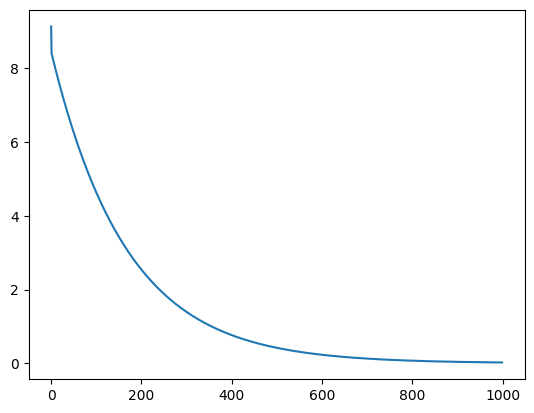

In [ ]:
plt.plot(losses);

# Task 9: Predictions

In [ ]:
model_untrained = Model(2)

x_test, y_test = generate_examples(500)
print(x_test.shape, y_test.shape)

(500, 2) (500, 1)


In [ ]:
preds_untrained = model_untrained.forward_pass(x_test)
preds_trained = model.forward_pass(x_test)

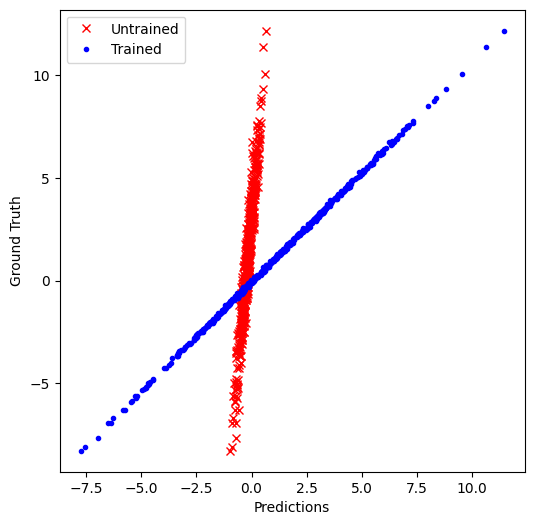

In [ ]:
plt.figure(figsize=(6,6))
plt.plot(preds_untrained, y_test, 'rx', label='Untrained')
plt.plot(preds_trained, y_test, 'b.', label='Trained')
plt.legend()
plt.xlabel('Predictions')
plt.ylabel('Ground Truth')
plt.show()